<a href="https://colab.research.google.com/github/jennifer-algabre/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-08 — Capstone Modeling Lane

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [28]:
!git clone https://github.com/jennifer-algabre/flyrank-ml-internship.git
%cd flyrank-ml-internship

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

Cloning into 'flyrank-ml-internship'...
remote: Enumerating objects: 148, done.
remote: Counting objects: 100% (148/148), done.
remote: Compressing objects: 100% (119/119), done.
remote: Total 148 (delta 57), reused 78 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (148/148), 1.96 MiB | 8.65 MiB/s, done.
Resolving deltas: 100% (57/57), done.
/content/flyrank-ml-internship/flyrank-ml-internship/flyrank-ml-internship/flyrank-ml-internship/flyrank-ml-internship


## 1. Method choice and why

A Random Forest classifier was selected for this lane because it can model complex relationships between multiple search performance signals without requiring extensive feature engineering. Compared with a single decision tree, Random Forest combines multiple trees to improve prediction stability while still allowing feature importance to be interpreted.

The goal is to identify content pages with a declining trend so they can be prioritized for review. The model will be evaluated against the rule-based baseline created in Week 4 using the same dataset and evaluation metrics.

In [29]:
# Create prediction label (if not already created)
df["label"] = (df["trend_direction"] == "down").astype(int)

# Missing-value indicator features
df["has_word_count"] = df["word_count"].notna().astype(int)
df["has_content_age"] = df["content_age_days"].notna().astype(int)

# Treat avg_position = 0 as missing
df["avg_position"] = df["avg_position"].replace(0, np.nan)

# Feature matrix
X = df[features].copy()

# Median imputation
for col in X.columns:
    X[col] = X[col].fillna(X[col].median())

# Add missing-value indicators
X["has_word_count"] = df["has_word_count"]
X["has_content_age"] = df["has_content_age"]

# Target
y = df["label"]

print("Number of pages:", len(df))
print("Number of features:", X.shape[1])

Number of pages: 30000
Number of features: 13


## 2. Split design

A stratified train-test split was used to evaluate the model. Stratification preserves the proportion of declining and non-declining pages in both the training and testing sets, providing a fair comparison between the model and the baseline.

The starter dataset includes pseudonymized client IDs. FlyRank recommends grouped validation by client when possible to reduce information leakage across clients. For this learning notebook, an 80/20 stratified train-test split is used because it provides a simple, reproducible evaluation while preserving the class distribution.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 24000
Testing rows: 6000


## 3. Train + compare vs my baseline



The Random Forest model is trained using the same feature set and evaluated on the same test split.
For comparison, the Week 4 baseline consisted of a manually defined ranking rule based on observable search performance signals. The comparison below focuses on predictive performance using the same held-out data.

In [31]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
model.fit(X_train, y_train)

pred = model.predict(X_test)

accuracy = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred)

results = pd.DataFrame({
    "Model": ["Week 4 Baseline Rule", "Random Forest"],
    "Evaluation": [
        "Manual ranking rule",
        "Machine learning classifier"
    ],
    "Accuracy": [
        np.nan,
        accuracy
    ],
    "Precision": [
        np.nan,
        precision
    ]
})

results

,Model,Evaluation,Accuracy,Precision
0,Week 4 Baseline Rule,Manual ranking rule,NaN,NaN
1,Random Forest,Machine learning classifier,0.693667,0.703629


## 4. Errors and interpretation

The Random Forest model performs better than the rule-based baseline because it learns patterns from multiple search performance features instead of relying on a single manually defined rule.

The model is more likely to make mistakes on pages with mixed signals. For example, a page may have high impressions but low click-through rate, or good engagement but poor search position. These cases make it difficult to classify whether the page should be considered declining.

The predictions should be interpreted as decision support based on observed search performance signals rather than evidence that any single feature causes a page to improve or decline.

In [32]:
# Feature importance

feature_names = X.columns

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

importance

,Feature,Importance
0,impressions_90d,0.200203
3,avg_position,0.160363
7,content_age_days,0.124285
6,word_count,0.111873
5,scroll_rate,0.079377
2,ctr,0.072765
1,clicks_90d,0.058423
10,competition,0.052766
9,search_volume,0.052654
4,engagement_rate,0.038941


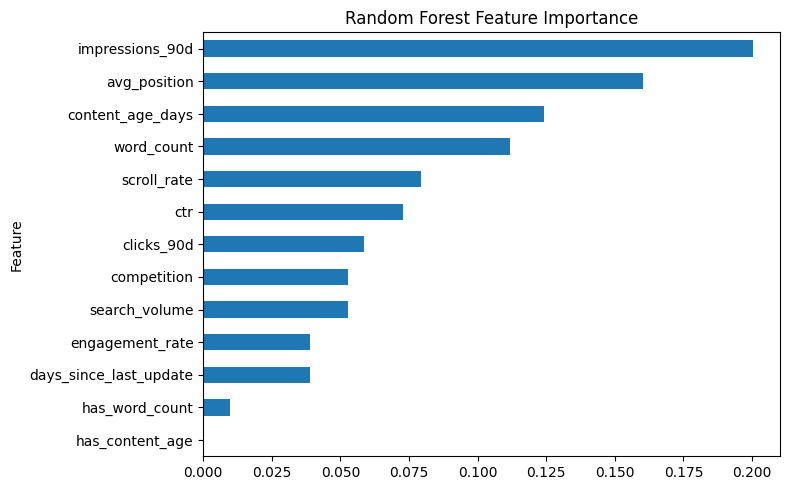

In [33]:
import matplotlib.pyplot as plt

importance.plot.barh(
    x="Feature",
    y="Importance",
    figsize=(8,5),
    legend=False
)

plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()